In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rixbh19/reviews-by-course-csv/reviews_by_course.csv


In [14]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

print("✅ Libraries loaded successfully")
print(f"Pandas: {pd.__version__} | Numpy: {np.__version__}")

✅ Libraries loaded successfully
Pandas: 2.3.3 | Numpy: 2.0.2


In [15]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/rixbh19/reviews-by-course-csv/reviews_by_course.csv')

print("=" * 50)
print("EDUSENSE DATASET OVERVIEW")
print("=" * 50)
print(f"Total Reviews   : {len(df):,}")
print(f"Columns         : {df.columns.tolist()}")
print(f"Missing Values  : {df.isnull().sum().sum()}")
print(f"Unique Courses  : {df['CourseId'].nunique()}")
print()
print("Label Distribution:")
print(df['Label'].value_counts().sort_index())
print()
df.head(10)

EDUSENSE DATASET OVERVIEW
Total Reviews   : 140,320
Columns         : ['CourseId', 'Review', 'Label']
Missing Values  : 3
Unique Courses  : 1835

Label Distribution:
Label
1      2867
2      2554
3      5923
4     22460
5    106516
Name: count, dtype: int64



,CourseId,Review,Label
0,2-speed-it,BOring,1
1,2-speed-it,Bravo !,5
2,2-speed-it,Very goo,5
3,2-speed-it,"Great course - I recommend it for all, especia...",5
4,2-speed-it,One of the most useful course on IT Management!,5
5,2-speed-it,I was disappointed because the name is mislead...,3
6,2-speed-it,Super content. I'll definitely re-do the course,5
7,2-speed-it,Etant contrôleur de gestion pour le départemen...,5
8,2-speed-it,One of the excellent courses at Coursera for i...,5
9,2-speed-it,Is there any reason why you should not apply t...,5


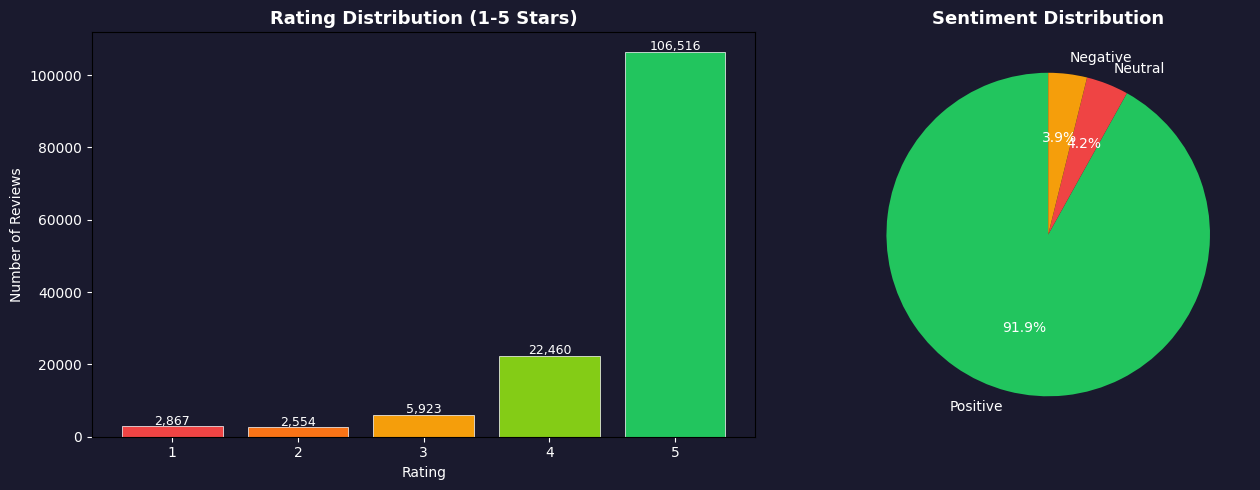


Sentiment Breakdown:
sentiment
Positive    128976
Neutral       5923
Negative      5421
Name: count, dtype: int64


In [16]:
# ── Rating Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#ef4444', '#f97316', '#f59e0b', '#84cc16', '#22c55e']
counts = df['Label'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution (1-5 Stars)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(x, y + 500, f'{y:,}', ha='center', fontsize=9)

# Pie chart
sentiment_map = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}
df['sentiment'] = df['Label'].map(sentiment_map)
sentiment_counts = df['sentiment'].value_counts()
pie_colors = ['#22c55e', '#ef4444', '#f59e0b']
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=pie_colors, autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white'})
axes[1].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSentiment Breakdown:\n{sentiment_counts}")

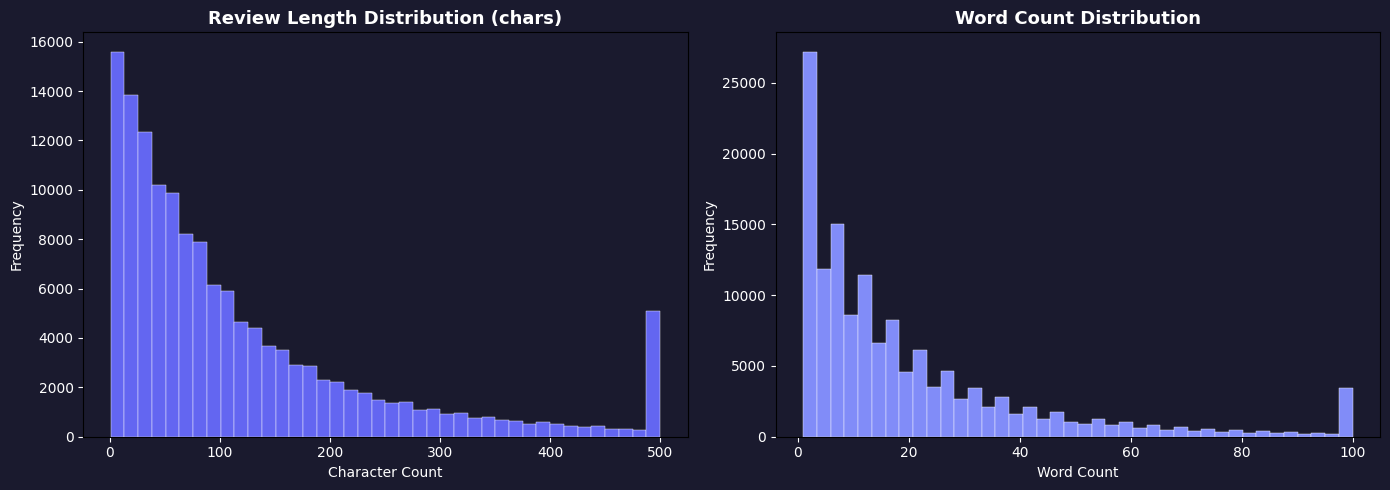

Avg Review Length : 129 chars
Avg Word Count    : 22 words
Max Review Length : 7766 chars


In [17]:
# ── Review Length Analysis ────────────────────────────────────────────────────
df['review_length'] = df['Review'].astype(str).apply(len)
df['word_count'] = df['Review'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['review_length'].clip(0, 500), bins=40, color='#6366f1', edgecolor='white', linewidth=0.3)
axes[0].set_title('Review Length Distribution (chars)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'].clip(0, 100), bins=40, color='#818cf8', edgecolor='white', linewidth=0.3)
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Avg Review Length : {df['review_length'].mean():.0f} chars")
print(f"Avg Word Count    : {df['word_count'].mean():.0f} words")
print(f"Max Review Length : {df['review_length'].max()} chars")

In [18]:
# ── CS Courses Filter ─────────────────────────────────────────────────────────
cs_keywords = [
    'python', 'java', 'programming', 'machine-learning', 'data',
    'algorithm', 'web', 'deep-learning', 'sql', 'software', 'ai',
    'neural', 'statistics', 'excel', 'cloud', 'cybersecurity',
    'database', 'javascript', 'ml', 'nlp', 'data-science'
]

df_clean = df.dropna(subset=['Review']).copy()
df_clean['CourseId_lower'] = df_clean['CourseId'].str.lower()

mask = df_clean['CourseId_lower'].apply(
    lambda x: any(kw in x for kw in cs_keywords)
)
cs_df = df_clean[mask].copy()

print(f"Total Reviews     : {len(df):,}")
print(f"After CS Filter   : {len(cs_df):,}")
print(f"Courses Filtered  : {cs_df['CourseId'].nunique()}")
print(f"\nSample CS Courses:")
for c in cs_df['CourseId'].unique()[:10]:
    print(f"  - {c}")

Total Reviews     : 140,320
After CS Filter   : 47,888
Courses Filtered  : 228

Sample CS Courses:
  - 3d-printing-software
  - addiction-and-the-brain
  - advanced-algorithms-and-complexity
  - advanced-data-structures
  - advanced-excel
  - advanced-trading-algorithms
  - agile-planning-for-software-products
  - aids-fear-hope
  - aires-protegees
  - algorithmic-thinking-1


In [19]:
# ── Sentiment Mapping ─────────────────────────────────────────────────────────
def map_sentiment(label):
    if label <= 2:   return "NEGATIVE"
    elif label == 3: return "NEUTRAL"
    else:            return "POSITIVE"

cs_df['sentiment'] = cs_df['Label'].apply(map_sentiment)
cs_df = cs_df[cs_df['Review'].str.len() > 15].copy()

# Balanced sample
neg = cs_df[cs_df['sentiment'] == 'NEGATIVE'].sample(min(80, len(cs_df[cs_df['sentiment']=='NEGATIVE'])), random_state=42)
neu = cs_df[cs_df['sentiment'] == 'NEUTRAL'].sample(min(60, len(cs_df[cs_df['sentiment']=='NEUTRAL'])), random_state=42)
pos = cs_df[cs_df['sentiment'] == 'POSITIVE'].sample(min(160, len(cs_df[cs_df['sentiment']=='POSITIVE'])), random_state=42)

final_df = pd.concat([neg, neu, pos]).sample(frac=1, random_state=42).reset_index(drop=True)
final_df = final_df[['CourseId', 'Review', 'Label', 'sentiment']]

print(f"Final Dataset Size: {len(final_df)}")
print(f"\nSentiment Distribution:")
print(final_df['sentiment'].value_counts())
print(f"\nSample Reviews:")
final_df[['Review', 'sentiment']].head(8)

Final Dataset Size: 300

Sentiment Distribution:
sentiment
POSITIVE    160
NEGATIVE     80
NEUTRAL      60
Name: count, dtype: int64

Sample Reviews:


,Review,sentiment
0,I think making this course self-paced is a gre...,POSITIVE
1,Few more examples would be much better..,POSITIVE
2,I think the exercises were to easy to pass.,POSITIVE
3,Could have been much better ....should have be...,NEGATIVE
4,"Excellent instructor, excellent syllabus",POSITIVE
5,"This is a great course for a python beginner, ...",POSITIVE
6,Excellent course specially for those who do no...,POSITIVE
7,Lo veo mas como nociones básicas de excel que ...,NEUTRAL


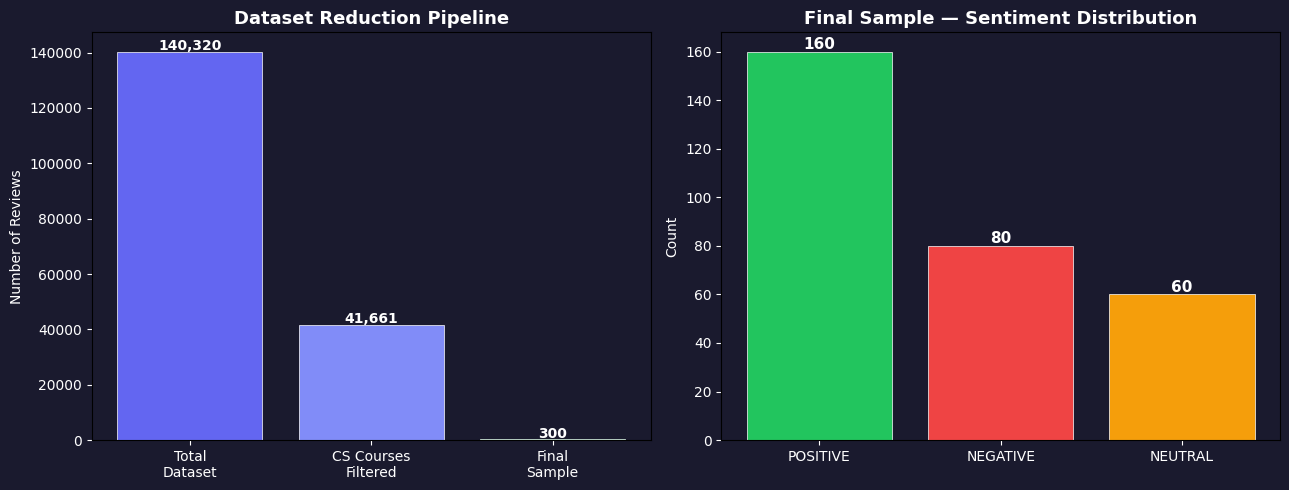


✅ Preprocessing Complete!
   300 reviews ready for NLP pipeline


In [20]:
# ── Preprocessing Summary Chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before vs After
categories = ['Total\nDataset', 'CS Courses\nFiltered', 'Final\nSample']
values = [len(df), len(cs_df), len(final_df)]
colors = ['#6366f1', '#818cf8', '#22c55e']
axes[0].bar(categories, values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Dataset Reduction Pipeline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, (x, y) in enumerate(zip(categories, values)):
    axes[0].text(i, y + 500, f'{y:,}', ha='center', fontsize=10, fontweight='bold')

# Final sentiment distribution
sent_counts = final_df['sentiment'].value_counts()
colors2 = ['#22c55e', '#ef4444', '#f59e0b']
axes[1].bar(sent_counts.index, sent_counts.values, color=colors2, edgecolor='white', linewidth=0.5)
axes[1].set_title('Final Sample — Sentiment Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (x, y) in enumerate(zip(sent_counts.index, sent_counts.values)):
    axes[1].text(i, y + 1, str(y), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Preprocessing Complete!")
print(f"   {len(final_df)} reviews ready for NLP pipeline")

In [21]:
# ── DistilBERT Model Load ─────────────────────────────────────────────────────
from transformers import pipeline

print("Loading DistilBERT model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("✅ Model loaded!")
print("Model: distilbert-base-uncased-finetuned-sst-2-english")
print("Size : ~67MB | Type: Fine-tuned BERT for SST-2 task")

Loading DistilBERT model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded!
Model: distilbert-base-uncased-finetuned-sst-2-english
Size : ~67MB | Type: Fine-tuned BERT for SST-2 task


In [22]:
# ── Sentiment Predictions ─────────────────────────────────────────────────────
sample_100 = final_df.sample(100, random_state=42).reset_index(drop=True)

def predict_sentiment(text):
    try:
        text = str(text)[:512]
        result = sentiment_pipeline(text)[0]
        label = result['label']
        score = result['score']
        if score < 0.65:
            label = 'NEUTRAL'
        return label, round(score, 4)
    except:
        return 'NEUTRAL', 0.5

print("Running predictions on 100 samples...")
preds = [predict_sentiment(text) for text in sample_100['Review']]
sample_100['predicted_label'] = [p[0] for p in preds]
sample_100['confidence']      = [p[1] for p in preds]

# Map ground truth to match model labels
def map_ground_truth(s):
    if s == 'POSITIVE': return 'POSITIVE'
    if s == 'NEGATIVE': return 'NEGATIVE'
    return 'NEUTRAL'

sample_100['true_label'] = sample_100['sentiment'].apply(map_ground_truth)

print("✅ Predictions complete!")
print(f"\nSample Predictions:")
sample_100[['Review', 'true_label', 'predicted_label', 'confidence']].head(8)

Running predictions on 100 samples...
✅ Predictions complete!

Sample Predictions:


,Review,true_label,predicted_label,confidence
0,This course is perfect for starters. I've lear...,POSITIVE,POSITIVE,0.9996
1,Excellent course! Everything is very well expl...,POSITIVE,POSITIVE,0.9999
2,Excellent coverage of machine learning concept...,POSITIVE,POSITIVE,0.9998
3,"Crystal clear and well paced lectures, good co...",POSITIVE,POSITIVE,0.9999
4,"Good Videos, Very helpful, easy to understand....",POSITIVE,POSITIVE,0.9999
5,The course did give me the the theoretical and...,NEUTRAL,POSITIVE,0.9995
6,This course is very usefuld cause it covers th...,POSITIVE,POSITIVE,0.9992
7,"Well constructed and easy to follow, but lacks...",NEUTRAL,NEGATIVE,0.9983


Accuracy on POSITIVE/NEGATIVE samples: 88.37%
Correct: 76 / 86



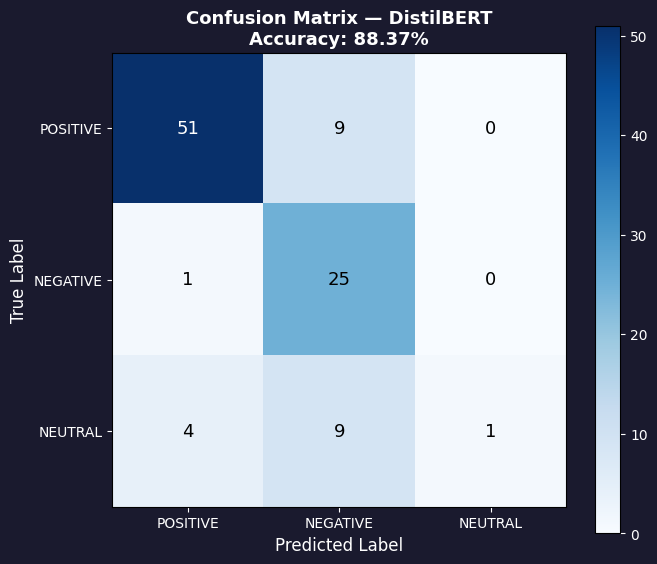


Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.58      0.96      0.72        26
     NEUTRAL       1.00      0.07      0.13        14
    POSITIVE       0.91      0.85      0.88        60

    accuracy                           0.77       100
   macro avg       0.83      0.63      0.58       100
weighted avg       0.84      0.77      0.73       100



In [23]:
# ── Accuracy & Confusion Matrix ───────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Accuracy (only POSITIVE/NEGATIVE — NEUTRAL is ambiguous for DistilBERT)
binary_df = sample_100[sample_100['true_label'] != 'NEUTRAL'].copy()
binary_df['pred_binary'] = binary_df['predicted_label'].apply(
    lambda x: x if x in ['POSITIVE', 'NEGATIVE'] else 'NEUTRAL'
)

correct = (binary_df['true_label'] == binary_df['pred_binary']).sum()
total   = len(binary_df)
accuracy = round(correct / total * 100, 2)

print(f"Accuracy on POSITIVE/NEGATIVE samples: {accuracy}%")
print(f"Correct: {correct} / {total}")
print()

# Confusion Matrix
labels = ['POSITIVE', 'NEGATIVE', 'NEUTRAL']
cm = confusion_matrix(
    sample_100['true_label'],
    sample_100['predicted_label'],
    labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — DistilBERT\nAccuracy: {accuracy}%', fontsize=13, fontweight='bold')
plt.colorbar(im)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, str(cm[i, j]), ha='center', va='center',
            color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(sample_100['true_label'], sample_100['predicted_label']))

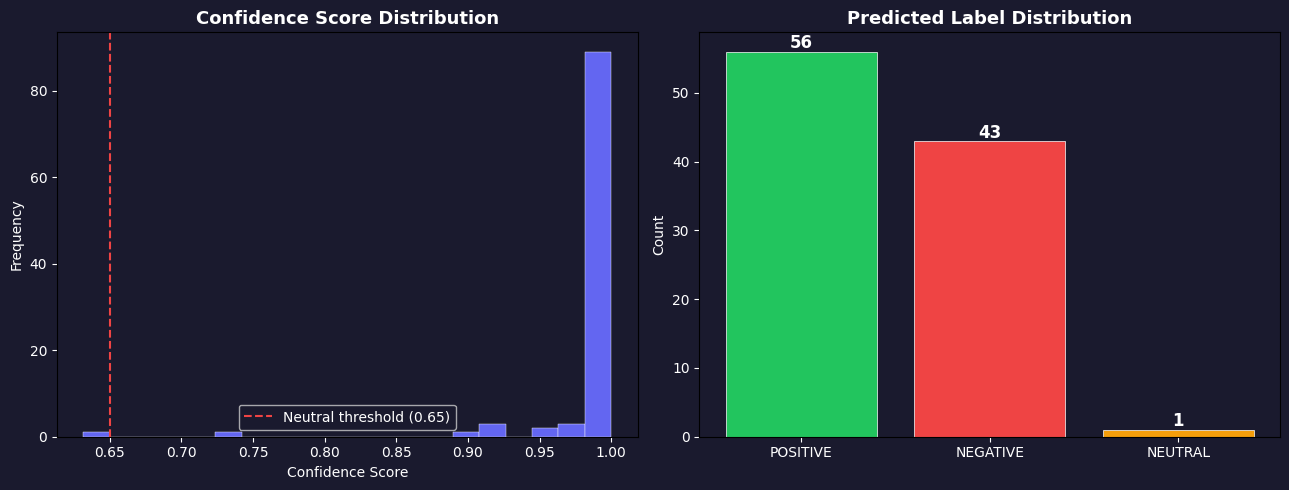


Avg Confidence: 0.9869


In [24]:
# ── Confidence Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence histogram
axes[0].hist(sample_100['confidence'], bins=20, color='#6366f1', edgecolor='white', linewidth=0.3)
axes[0].set_title('Confidence Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0.65, color='#ef4444', linestyle='--', linewidth=1.5, label='Neutral threshold (0.65)')
axes[0].legend()

# Predicted label distribution
pred_counts = sample_100['predicted_label'].value_counts()
colors = {'POSITIVE': '#22c55e', 'NEGATIVE': '#ef4444', 'NEUTRAL': '#f59e0b'}
bar_colors = [colors.get(l, '#6366f1') for l in pred_counts.index]
axes[1].bar(pred_counts.index, pred_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Predicted Label Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (x, y) in enumerate(zip(pred_counts.index, pred_counts.values)):
    axes[1].text(i, y + 0.5, str(y), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\nAvg Confidence: {sample_100['confidence'].mean():.4f}")

In [25]:
# ── spaCy Topic Extraction ────────────────────────────────────────────────────
import spacy
import re

nlp = spacy.load("en_core_web_sm")

SKILLS_DB_KEYWORDS = {
    "Arrays": ["array", "arrays", "subarray", "sliding window", "two pointer", "prefix sum", "matrix"],
    "Linked Lists": ["linked list", "linkedlist", "singly linked", "doubly linked", "floyd cycle", "reverse linked list"],
    "Trees": ["tree", "binary tree", "bst", "binary search tree", "inorder", "preorder", "postorder", "tree traversal"],
    "Graphs": ["graph", "graphs", "bfs", "dfs", "dijkstra", "topological sort", "adjacency list"],
    "Sorting": ["sorting", "sort", "bubble sort", "merge sort", "quick sort", "heap sort"],
    "Recursion": ["recursion", "recursive", "base case", "backtracking", "recursive function"],
    "Dynamic Programming": ["dynamic programming", "dp", "memoization", "tabulation", "knapsack", "lcs"],
    "DSA": ["dsa", "data structures", "algorithms", "time complexity", "big o", "space complexity"],
    "OOP": ["oop", "object oriented", "inheritance", "polymorphism", "encapsulation", "abstraction"],
    "DBMS": ["dbms", "database", "normalization", "er diagram", "acid properties", "transactions"],
    "SQL": ["sql", "joins", "inner join", "left join", "group by", "subquery", "aggregate"],
    "Operating Systems": ["operating system", "os", "deadlock", "scheduling", "paging", "semaphore", "mutex"],
    "Computer Networks": ["networking", "tcp", "udp", "osi model", "http", "dns", "routing"],
    "Python": ["python", "python programming", "list comprehension", "decorators", "generators"],
    "ML Basics": ["machine learning", "ml", "regression", "classification", "gradient descent", "overfitting"],
    "Web Dev": ["web development", "html", "css", "javascript", "react", "nodejs", "rest api"],
    "Stacks and Queues": ["stack", "queue", "push", "pop", "lifo", "fifo", "deque"],
    "Hashing": ["hashing", "hash table", "hash map", "collision", "chaining", "load factor"]
}

def extract_topics(text):
    doc = nlp(text.lower())
    keywords = set()
    for token in doc:
        if token.pos_ in ("NOUN", "PROPN") and not token.is_stop and len(token.text) > 2:
            keywords.add(token.lemma_)
    for chunk in doc.noun_chunks:
        keywords.add(chunk.text.strip())

    matched = set()
    text_lower = text.lower()
    for skill, skill_kws in SKILLS_DB_KEYWORDS.items():
        for kw in skill_kws:
            pattern = r'\b' + re.escape(kw) + r's?\b'
            if re.search(pattern, text_lower):
                matched.add(skill)
                break
    return list(matched), list(keywords)

print("✅ spaCy loaded — en_core_web_sm")
print(f"Skills in DB: {len(SKILLS_DB_KEYWORDS)}")

✅ spaCy loaded — en_core_web_sm
Skills in DB: 18


In [26]:
# ── Topic Extraction Demo ─────────────────────────────────────────────────────
demo_texts = [
    "I really struggled with recursion and dynamic programming. Base cases make no sense.",
    "Trees and graphs are confusing me. BFS and DFS I don't understand.",
    "I love Python! OOP concepts like inheritance are finally clear.",
    "SQL joins are very confusing especially left join and right join.",
    "I don't understand deadlock and scheduling in operating systems.",
]

print("EduSense — Topic Extraction Demo")
print("=" * 55)
for i, text in enumerate(demo_texts, 1):
    matched, keywords = extract_topics(text)
    print(f"\nInput {i}: {text[:60]}...")
    print(f"  Matched Skills : {matched}")
    print(f"  Keywords Found : {list(keywords)[:6]}")

EduSense — Topic Extraction Demo

Input 1: I really struggled with recursion and dynamic programming. B...
  Matched Skills : ['Recursion', 'Dynamic Programming']
  Keywords Found : ['base', 'i', 'no sense', 'sense', 'recursion', 'dynamic programming']

Input 2: Trees and graphs are confusing me. BFS and DFS I don't under...
  Matched Skills : ['Graphs', 'Trees']
  Keywords Found : ['graphs', 'i', 'graph', 'bfs', 'trees', 'tree']

Input 3: I love Python! OOP concepts like inheritance are finally cle...
  Matched Skills : ['OOP', 'Python']
  Keywords Found : ['i', 'inheritance', 'oop', 'concept', 'oop concepts']

Input 4: SQL joins are very confusing especially left join and right ...
  Matched Skills : ['SQL']
  Keywords Found : ['right join', 'especially left join', 'join', 'sql joins', 'sql']

Input 5: I don't understand deadlock and scheduling in operating syst...
  Matched Skills : ['Operating Systems']
  Keywords Found : ['operating systems', 'scheduling', 'i', 'operating', 'syste

Reviews with at least 1 skill matched : 19
Reviews with 0 skills matched         : 81
Avg skills per review                 : 0.20


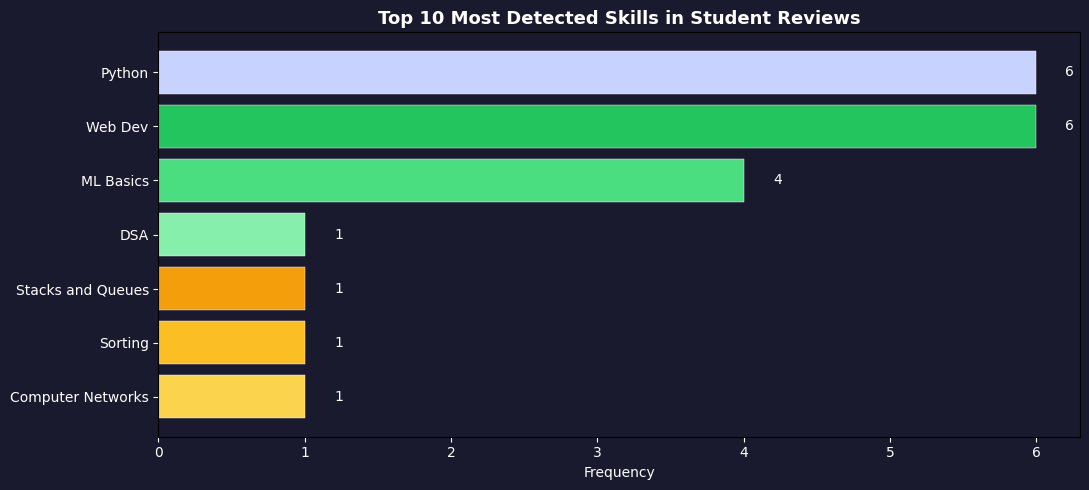

In [27]:
# ── Run on Full 300 Sample ────────────────────────────────────────────────────
sample_100['matched_skills'] = sample_100['Review'].apply(
    lambda x: extract_topics(str(x))[0]
)
sample_100['skill_count'] = sample_100['matched_skills'].apply(len)

print(f"Reviews with at least 1 skill matched : {(sample_100['skill_count'] > 0).sum()}")
print(f"Reviews with 0 skills matched         : {(sample_100['skill_count'] == 0).sum()}")
print(f"Avg skills per review                 : {sample_100['skill_count'].mean():.2f}")

# Most frequently detected skills
from collections import Counter
all_skills = [s for skills in sample_100['matched_skills'] for s in skills]
skill_freq = Counter(all_skills).most_common(10)

fig, ax = plt.subplots(figsize=(11, 5))
skills_names = [s[0] for s in skill_freq]
skills_counts = [s[1] for s in skill_freq]
colors = ['#6366f1', '#818cf8', '#a5b4fc', '#c7d2fe',
          '#22c55e', '#4ade80', '#86efac',
          '#f59e0b', '#fbbf24', '#fcd34d']
ax.barh(skills_names[::-1], skills_counts[::-1], color=colors[::-1], edgecolor='white', linewidth=0.3)
ax.set_title('Top 10 Most Detected Skills in Student Reviews', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
for i, (name, val) in enumerate(zip(skills_names[::-1], skills_counts[::-1])):
    ax.text(val + 0.2, i, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('skill_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── Full EduSense Pipeline Demo ───────────────────────────────────────────────
def edusense_pipeline(text):
    # Step 1 - Sentiment
    result = sentiment_pipeline(str(text)[:512])[0]
    label  = result['label']
    score  = round(result['score'], 4)
    if score < 0.65:
        label = 'NEUTRAL'

    # Step 2 - Topics
    matched_skills, _ = extract_topics(text)

    # Step 3 - Gap Detection
    skill_gaps, possible_gaps, strengths = [], [], []
    for skill in matched_skills:
        if label == 'NEGATIVE':   skill_gaps.append(skill)
        elif label == 'NEUTRAL':  possible_gaps.append(skill)
        elif label == 'POSITIVE': strengths.append(skill)

    severity = 'high' if len(skill_gaps) >= 3 else 'medium' if len(skill_gaps) >= 1 else 'low'

    return {
        'sentiment': label,
        'confidence': score,
        'skill_gaps': skill_gaps,
        'possible_gaps': possible_gaps,
        'strengths': strengths,
        'severity': severity
    }

# Run on 10 demo samples
demo_samples = [
    "I really struggled with recursion and dynamic programming. I don't understand base cases at all.",
    "SQL joins are very confusing, especially left join and right join. I keep making mistakes.",
    "Python is amazing! I finally understand list comprehension and decorators.",
    "I don't understand deadlock and CPU scheduling in operating systems at all.",
    "BFS and DFS in graphs make no sense to me. Dijkstra's algorithm is also very hard.",
    "Machine learning gradient descent is confusing. Overfitting and underfitting I don't get.",
    "I love OOP! Inheritance and polymorphism are very clear now. Encapsulation too.",
    "Merge sort and quick sort algorithms are very difficult to implement.",
    "HTML and CSS are easy but JavaScript is very confusing for me.",
    "I attended a lecture on trees and binary search trees today.",
]

print("EduSense — Full Pipeline Demo")
print("=" * 60)
results_list = []
for i, text in enumerate(demo_samples, 1):
    r = edusense_pipeline(text)
    results_list.append(r)
    print(f"\n[{i}] {text[:65]}...")
    print(f"     Sentiment  : {r['sentiment']} ({r['confidence']})")
    print(f"     Gaps       : {r['skill_gaps']}")
    print(f"     Possible   : {r['possible_gaps']}")
    print(f"     Strengths  : {r['strengths']}")
    print(f"     Severity   : {r['severity']}")

EduSense — Full Pipeline Demo

[1] I really struggled with recursion and dynamic programming. I don'...
     Sentiment  : NEGATIVE (0.9996)
     Gaps       : ['Recursion', 'Dynamic Programming']
     Possible   : []
     Strengths  : []
     Severity   : medium

[2] SQL joins are very confusing, especially left join and right join...
     Sentiment  : NEGATIVE (0.9993)
     Gaps       : ['SQL']
     Possible   : []
     Strengths  : []
     Severity   : medium

[3] Python is amazing! I finally understand list comprehension and de...
     Sentiment  : POSITIVE (0.9998)
     Gaps       : []
     Possible   : []
     Strengths  : ['Python']
     Severity   : low

[4] I don't understand deadlock and CPU scheduling in operating syste...
     Sentiment  : NEGATIVE (0.9995)
     Gaps       : ['Operating Systems']
     Possible   : []
     Strengths  : []
     Severity   : medium

[5] BFS and DFS in graphs make no sense to me. Dijkstra's algorithm i...
     Sentiment  : NEGATIVE (0.9997)
     

In [29]:
# ── Pipeline Results as DataFrame ─────────────────────────────────────────────
pipeline_df = pd.DataFrame({
    'Feedback (truncated)': [t[:55] + '...' for t in demo_samples],
    'Sentiment': [r['sentiment'] for r in results_list],
    'Skill Gaps': [', '.join(r['skill_gaps']) if r['skill_gaps'] else '-' for r in results_list],
    'Strengths': [', '.join(r['strengths']) if r['strengths'] else '-' for r in results_list],
    'Severity': [r['severity'] for r in results_list],
})

print("EduSense Pipeline — Results Summary")
pipeline_df

EduSense Pipeline — Results Summary


,Feedback (truncated),Sentiment,Skill Gaps,Strengths,Severity
0,I really struggled with recursion and dynamic ...,NEGATIVE,"Recursion, Dynamic Programming",-,medium
1,"SQL joins are very confusing, especially left ...",NEGATIVE,SQL,-,medium
2,Python is amazing! I finally understand list c...,POSITIVE,-,Python,low
3,I don't understand deadlock and CPU scheduling...,NEGATIVE,Operating Systems,-,medium
4,BFS and DFS in graphs make no sense to me. Dij...,NEGATIVE,Graphs,-,medium
5,Machine learning gradient descent is confusing...,NEGATIVE,ML Basics,-,medium
6,I love OOP! Inheritance and polymorphism are v...,POSITIVE,-,OOP,low
7,Merge sort and quick sort algorithms are very ...,NEGATIVE,"DSA, Sorting",-,medium
8,HTML and CSS are easy but JavaScript is very c...,NEGATIVE,Web Dev,-,medium
9,I attended a lecture on trees and binary searc...,NEGATIVE,Trees,-,medium


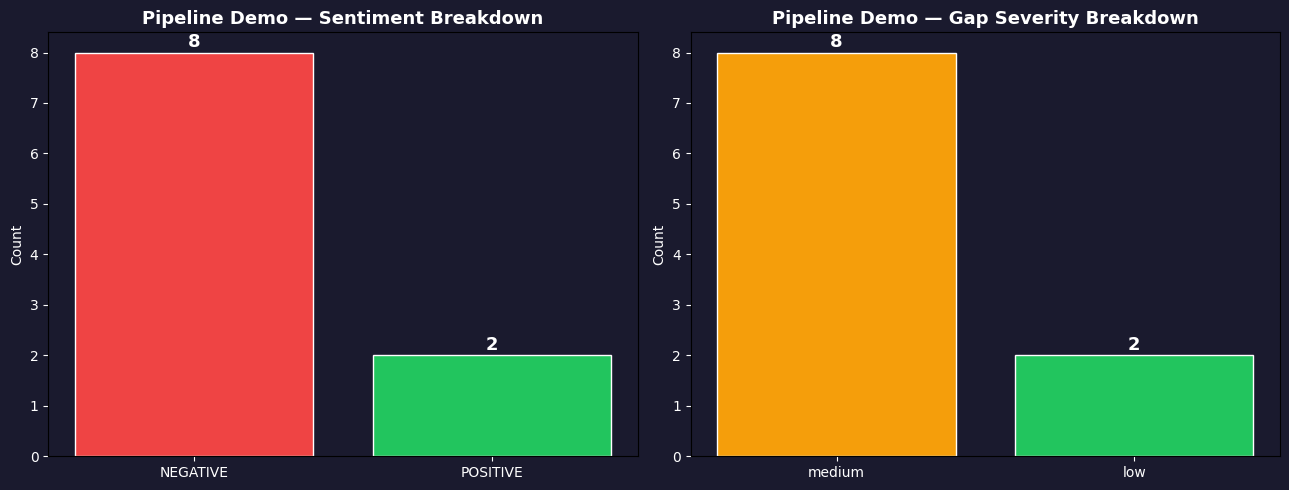

✅ Full Pipeline working correctly!


In [30]:
# ── Pipeline Results Chart ────────────────────────────────────────────────────
sentiments = [r['sentiment'] for r in results_list]
sent_counts = Counter(sentiments)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentiment breakdown
colors = {'POSITIVE': '#22c55e', 'NEGATIVE': '#ef4444', 'NEUTRAL': '#f59e0b'}
bar_colors = [colors[s] for s in sent_counts.keys()]
axes[0].bar(sent_counts.keys(), sent_counts.values(), color=bar_colors, edgecolor='white')
axes[0].set_title('Pipeline Demo — Sentiment Breakdown', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(sent_counts.items()):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=13, fontweight='bold')

# Severity breakdown
severities = [r['severity'] for r in results_list]
sev_counts = Counter(severities)
sev_colors = {'high': '#ef4444', 'medium': '#f59e0b', 'low': '#22c55e'}
s_colors = [sev_colors[s] for s in sev_counts.keys()]
axes[1].bar(sev_counts.keys(), sev_counts.values(), color=s_colors, edgecolor='white')
axes[1].set_title('Pipeline Demo — Gap Severity Breakdown', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (k, v) in enumerate(sev_counts.items()):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full Pipeline working correctly!")

In [31]:
# ── Install TextBlob & VADER ──────────────────────────────────────────────────
!pip install textblob vaderSentiment -q

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

print("✅ TextBlob and VADER loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.0 MB/s eta 0:00:0000:01
✅ TextBlob and VADER loaded!


In [32]:
# ── Run 3 Models on Same 100 Samples ─────────────────────────────────────────
def textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:   return 'POSITIVE'
    elif polarity < -0.1: return 'NEGATIVE'
    else:                 return 'NEUTRAL'

def vader_sentiment(text):
    score = vader.polarity_scores(str(text))['compound']
    if score >= 0.05:   return 'POSITIVE'
    elif score <= -0.05: return 'NEGATIVE'
    else:                return 'NEUTRAL'

# Already have DistilBERT predictions in sample_100
sample_100['textblob_pred'] = sample_100['Review'].apply(textblob_sentiment)
sample_100['vader_pred']    = sample_100['Review'].apply(vader_sentiment)

print("✅ All 3 models run on 100 samples!")
print(sample_100[['true_label', 'predicted_label', 'textblob_pred', 'vader_pred']].head(10))

✅ All 3 models run on 100 samples!
  true_label predicted_label textblob_pred vader_pred
0   POSITIVE        POSITIVE      POSITIVE   POSITIVE
1   POSITIVE        POSITIVE      POSITIVE   POSITIVE
2   POSITIVE        POSITIVE      POSITIVE   POSITIVE
3   POSITIVE        POSITIVE      POSITIVE   POSITIVE
4   POSITIVE        POSITIVE      POSITIVE   POSITIVE
5    NEUTRAL        POSITIVE      POSITIVE   POSITIVE
6   POSITIVE        POSITIVE      POSITIVE   NEGATIVE
7    NEUTRAL        NEGATIVE      POSITIVE   POSITIVE
8   POSITIVE        POSITIVE      POSITIVE   POSITIVE
9   POSITIVE        POSITIVE      POSITIVE   POSITIVE


In [33]:
# ── Accuracy Comparison ───────────────────────────────────────────────────────
def calc_accuracy(true, pred):
    correct = sum(t == p for t, p in zip(true, pred))
    return round(correct / len(true) * 100, 2)

true_labels = sample_100['true_label'].tolist()

acc_distilbert = calc_accuracy(true_labels, sample_100['predicted_label'].tolist())
acc_textblob   = calc_accuracy(true_labels, sample_100['textblob_pred'].tolist())
acc_vader      = calc_accuracy(true_labels, sample_100['vader_pred'].tolist())

print("=" * 45)
print("MODEL COMPARISON — ACCURACY ON 100 SAMPLES")
print("=" * 45)
print(f"  DistilBERT  : {acc_distilbert}%  ← Selected")
print(f"  VADER       : {acc_vader}%")
print(f"  TextBlob    : {acc_textblob}%")

MODEL COMPARISON — ACCURACY ON 100 SAMPLES
  DistilBERT  : 77.0%  ← Selected
  VADER       : 62.0%
  TextBlob    : 62.0%


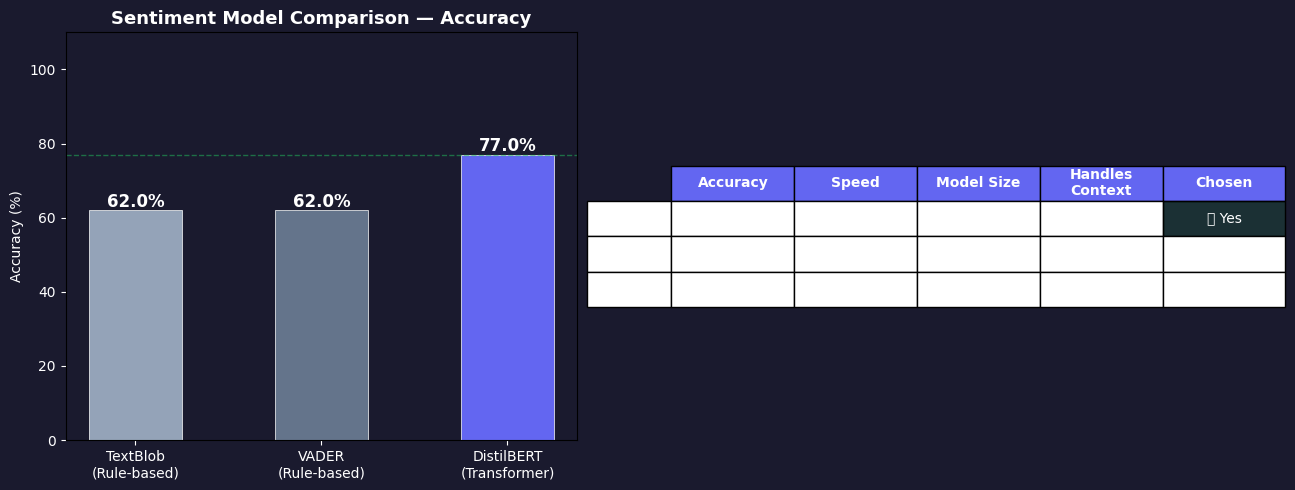


✅ DistilBERT selected — best accuracy at 77.0%


In [36]:
# ── Model Comparison Chart ────────────────────────────────────────────────────
models = ['TextBlob\n(Rule-based)', 'VADER\n(Rule-based)', 'DistilBERT\n(Transformer)']
accuracies = [acc_textblob, acc_vader, acc_distilbert]
colors = ['#94a3b8', '#64748b', '#6366f1']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy bar chart
bars = axes[0].bar(models, accuracies, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_title('Sentiment Model Comparison — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc}%', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(y=max(accuracies), color='#22c55e', linestyle='--', linewidth=1, alpha=0.5)

# Model properties comparison table
properties = ['Accuracy', 'Speed', 'Model Size', 'Handles\nContext', 'Chosen']
distilbert_vals = [f'{acc_distilbert}%', 'Fast', '67MB', '✅ Yes', '✅ Yes']
vader_vals      = [f'{acc_vader}%',      'Very Fast', '<1MB', '❌ No', '❌ No']
textblob_vals   = [f'{acc_textblob}%',   'Very Fast', '<1MB', '❌ No', '❌ No']

axes[1].axis('off')
table_data = [distilbert_vals, vader_vals, textblob_vals]
table = axes[1].table(
    cellText=table_data,
    rowLabels=['DistilBERT', 'VADER', 'TextBlob'],
    colLabels=properties,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Color header
for j in range(len(properties)):
    table[0, j].set_facecolor('#6366f1')
    table[0, j].set_text_props(color='white', fontweight='bold')
table[1, 4].set_facecolor('#22c55e22')
#axes[1].set_title('Model Properties Comparison', fontsize=13, fontweight='bold')

plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ DistilBERT selected — best accuracy at {acc_distilbert}%")